# PROYECTO TERCIO 2: DIAGNOSTICO DE CÁNCER DE MAMA

## Diseño  del problema y del modelo

El problema consiste en determinar, a partir de las características citológicas de una muestra de tejido mamario, si un tumor es **benigno** o **maligno**. Un diagnóstico temprano apoya la decisión clínica, por lo que es un caso real y relevante para clasificación.

**Dataset:** *Breast Cancer Wisconsin (Original)*, UCI Machine Learning Repository (Wolberg y Mangasarian). 

## Tipo de problema

**Clasificación binaria** (predicción categórica): benigno (0) o maligno (1). No es regresión porque la salida no es una cantidad numérica continua.

## Entradas (X) y objetivo (y)

| Elemento | Detalle |
|---|---|
| **X** (9 características) | `clump_thickness`, `uniformity_cell_size`, `uniformity_cell_shape`, `marginal_adhesion`, `single_epithelial_cell_size`, `bare_nuclei`, `bland_chromatin`, `normal_nucleoli`, `mitoses` |
| **y** | `clase`, recodificada de 2 (benigno) y 4 (maligno) a **0** y **1** |
| Descartada | `id_paciente` (identificador, no aporta patrón predictivo) |

id_paciente: Es el número de identificación único de la muestra médica de cada paciente. Nosotros lo eliminaremos del análisis porque no aporta ningún patrón matemático para predecir el cáncer.

clump_thickness (Grosor del agrupamiento): Evalúa si las células están apiladas en múltiples capas (común en células malignas) o agrupadas en una sola capa ordenada (común en células benignas).

uniformity_cell_size (Uniformidad del tamaño celular): Nos indica qué tan consistentes son las células en su tamaño. En un tejido sano, las células son casi del mismo tamaño; en el cáncer, varían drásticamente.

uniformity_cell_shape (Uniformidad de la forma celular): Funciona igual que la anterior, pero evaluando la forma. Las células cancerosas tienden a tener contornos irregulares y deformes.

marginal_adhesion (Adhesión marginal): Mide qué tan bien se "pegan" o adhieren las células entre sí. Las células normales suelen mantenerse unidas, mientras que las células malignas pierden esta cohesión y tienden a separarse.

single_epithelial_cell_size (Tamaño de célula epitelial individual): Mide el tamaño de un tipo específico de célula (epitelial). Un agrandamiento anormal en estas células es una señal temprana de que el tejido se está volviendo maligno.

bare_nuclei (Núcleos desnudos): Cuenta los núcleos celulares que se han quedado sin su capa exterior (citoplasma). Nota importante para nosotros

bland_chromatin (Cromatina blanda/uniforme): Describe la textura del material genético (ADN) dentro del núcleo. En células sanas, la textura se ve uniforme y "suave"; en las cancerosas, se agruma y se ve gruesa o áspera.

normal_nucleoli (Nucléolos normales): Los nucléolos son estructuras diminutas dentro del núcleo. En células sanas son apenas visibles, pero en células cancerosas se inflaman y se vuelven muy notorios.

mitoses (Mitosis): Nos indica la tasa de división y reproducción celular. Un nivel alto de mitosis refleja que las células se están multiplicando agresivamente y sin control, una característica principal del cáncer.

clase: Es nuestra variable objetivo (lo que queremos predecir). Como vimos en el manual, usa el valor 2 para los tumores benignos y 4 para los malignos, los cuales nosotros cambiaremos a 0 y 1 para nuestro perceptrón.

## Función de activación y de pérdida (justificación)

- **Activación de salida: sigmoide.** Lleva cualquier valor real al intervalo (0, 1), que se interpreta como la probabilidad de que el tumor sea maligno. La predicción final usa umbral 0.5: si ŷ ≥ 0.5 se clasifica como maligno.
- **Pérdida: entropía cruzada binaria (BCE).** Es la pérdida asociada a la sigmoide en clasificación, porque penaliza más las predicciones seguras pero equivocadas.

In [1]:
#LIBRERIAS NECESARIAS
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
os.makedirs('images', exist_ok=True)

#LOS NOMBRES FUERONS SACADOS DE EL ARCHIVO NAMES
nombres_columnas = ['id_paciente', 'clump_thickness', 'uniformity_cell_size', 'uniformity_cell_shape', 'marginal_adhesion', 'single_epithelial_cell_size',
 'bare_nuclei', 'bland_chromatin', 'normal_nucleoli', 'mitoses', 'clase']
data_set_cancer = pd.read_csv('data/breast-cancer-wisconsin.data', header=None, names=nombres_columnas, na_values='?')

print(data_set_cancer.head())
data_set_cancer.info()
data_set_cancer.describe()

   id_paciente  clump_thickness  uniformity_cell_size  uniformity_cell_shape  \
0      1000025                5                     1                      1   
1      1002945                5                     4                      4   
2      1015425                3                     1                      1   
3      1016277                6                     8                      8   
4      1017023                4                     1                      1   

   marginal_adhesion  single_epithelial_cell_size  bare_nuclei  \
0                  1                            2          1.0   
1                  5                            7         10.0   
2                  1                            2          2.0   
3                  1                            3          4.0   
4                  3                            2          1.0   

   bland_chromatin  normal_nucleoli  mitoses  clase  
0                3                1        1      2  
1             

,id_paciente,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,clase
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


# Limpieza de Datos

In [2]:
print(data_set_cancer.isnull().sum())

# 1) Eliminar el identificador ya que no es relevante para efectos del proyecto
df = data_set_cancer.drop(columns=['id_paciente']).copy()

#2) Recodificar la clase: 2 (benigno) a 0 y 4 (maligno) a 1
df['clase'] = df['clase'].map({2: 0, 4: 1})

# 3) Revisiones
print("Distribusion de clases: ", df['clase'].value_counts())
print("Proporcion de malignos: ", df['clase'].mean().round(3))
print("Filas duplicadas: ", df.duplicated().sum())
print("Forma final:", df.shape)

id_paciente                     0
clump_thickness                 0
uniformity_cell_size            0
uniformity_cell_shape           0
marginal_adhesion               0
single_epithelial_cell_size     0
bare_nuclei                    16
bland_chromatin                 0
normal_nucleoli                 0
mitoses                         0
clase                           0
dtype: int64
Distribusion de clases:  clase
0    458
1    241
Name: count, dtype: int64
Proporcion de malignos:  0.345
Filas duplicadas:  236
Forma final: (699, 10)


- Nulos: hay 16 valores faltantes solo en `bare_nuclei`. Se colocaran con la media claculada cuando se entrene el modelo para evitar fuga de datos.
- Clase: se modifico a 0/1 para que coincida con la salida de la sigmoide.

# Analisis exploratorio de datos

### Balance de clases

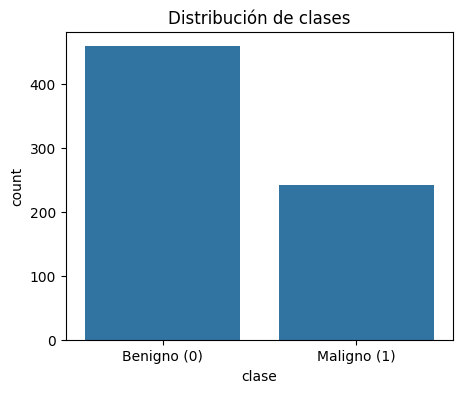

In [3]:
plt.figure(figsize=(5, 4))
sns.countplot(x='clase', data=df)
plt.xticks([0, 1], ['Benigno (0)', 'Maligno (1)'])
plt.title('Distribución de clases')
plt.savefig('images/eda_balance.png', dpi=200, bbox_inches='tight')
plt.show()

Existe una mayor proporcion de tumores benignos que malignos en la muestra, aproximante un 2:1; es importante la exactidud en cuanto la proporcion de estos datos para que una ves el modelo tome los datos, este no haga supociciones y sesgue el resultado por la mayoria.

### Histogramas de cada característica separados por clase

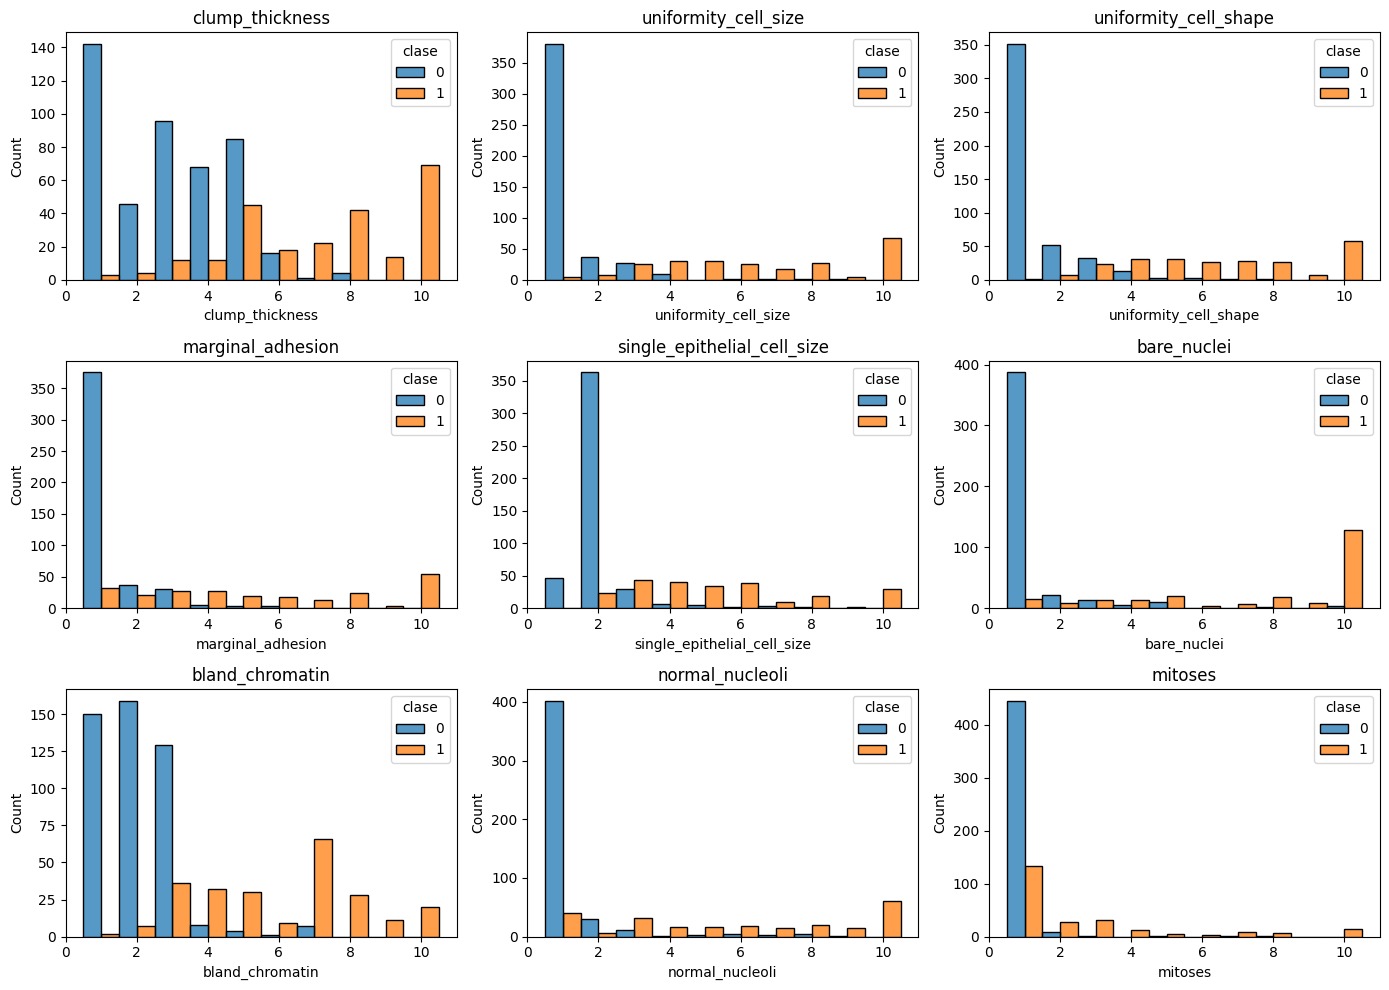

In [4]:
features = [c for c in df.columns if c != 'clase']
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(data=df, x=col, hue='clase', multiple='dodge', discrete=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('images/eda_histogramas.png', dpi=200, bbox_inches='tight')
plt.show()

#### Analisis grafica a grafica

1. `clump_thickness`(Grosor del grumo): Presenta una mayor frecuencia de ser benigno en los niveles bajs e intermedios, alcanzando un maximo en los niveles 1 y 3, mientra que la clase maligna predomina niveles altos como lo es el 10; por lo que a mayor grosor de la masa, este se asocia a malignidad.

2. `uniformity_cell_size` (Uniformidad del tamaño celular): Presenta un pico de la clase benigna en el valor 1, despues de ello, practicamene no vuelve a aparecer, mientras que la maligna se esparce desde 3 hasta 10 donde tiene su pico; por lo tanto si las celulas varian significativamente su tamaño, la probabilidad de que el tumorr se benigno es muy alta.

3. `uniformity_cell_shape` (Uniformidad de la forma celular): Tiene un comportamiento similar al del tamaño celular, por lo que nos dice que las celulas benignas presentan formas regulares, mientras que las malignas tieneden a tener deformaciones.

4. `marginal_adhesion` (Adhesión marginal): Esta tambien comparte una distribucion similar al de las 2 anteriores, lo que indica que las celulas malignas tienden a perder su adhesion y pueden presentar comportamientos anomalos en sus bordes, lo que facilitaria la dispersion del tumor.

5. `single_epithelial_cell_size` (Tamaño de la célula epitelial individual): Presenta una concentracion severa la clase benigna en el valor 2, mientras que en los casos 1 y 3 en adelante su participacion es casi nula, mientras que la clase maligna aprece en el rango de 3 a 10, por lo que un aumento en el tamaño de la celula epitlial indicaria un crecimiento celular anormal, que es propio de los tejidos malignos.

6. `bare_nuclei` (Nucleos desnudos):Una acumulacion masiva de la clase benigna en el valor 1,  mientras que la clase maligna aparece con una concentracion alta en el valor 10, lo que nos dice que la precenci recurrente de nucleos desnudos (sin citoplasma) en cantidades elevadas es un rasgo de tumores benignos.

7. `bland_chromatin` (Cromatina suave): Se ditribue la clase benigna en valores bajos (1, 2, 3), mientras que la clase maligna se concentra en valores altos (7, 8), por lo que nos revela que la textura cromatina dentro del nucleo de la celula cancerosa, pasa de ser uniforme y suave,  a una estructura grumosa o gruesa.

8. `normal_nucleoli` (Nucleos normales): Concentracion de la clase benigna absolutamente en el valor 1, y la clase maligna se distribuye a lo largo de 2 a 9, mientras que en el 10 se presenta una creciente; esto nos dice que en celulas benignas los nuclos son pequeños, mientras que en las malignas se vuelven prominenetes y aumentan su tamaño.

9. `mitoses` (Mitosis): La totalidad de los casos de celulas benignas se concentra en el valor 1, aunque algunos malignos se encuentran entre 1 y 2, presenta algo de presencia en los valores de 3 a 10; lo que nos dce que una baja tasa de mitosis no descarta el hecho de un cancer, sin embargo en valores mayores a 3 si es algo exclusivo de la malignidad.

### Matriz de correlación

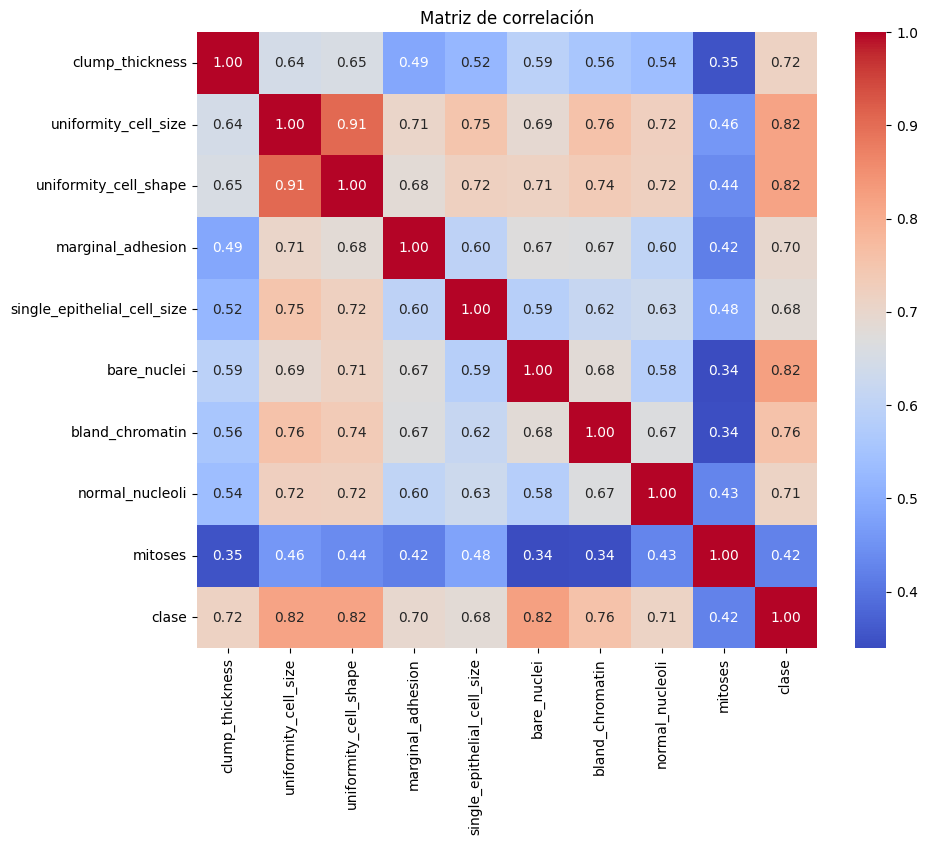

bare_nuclei                    0.823
uniformity_cell_shape          0.819
uniformity_cell_size           0.818
bland_chromatin                0.757
clump_thickness                0.716
normal_nucleoli                0.712
marginal_adhesion              0.697
single_epithelial_cell_size    0.683
mitoses                        0.423
Name: clase, dtype: float64


In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.savefig('images/eda_correlacion.png', dpi=200, bbox_inches='tight')
plt.show()

print(df.corr()['clase'].drop('clase').sort_values(ascending=False).round(3))

### Analisis

Esta grafica nos refuerza los dicho por las anteriores graficas presentadas, nos dice si la realcion entre variables, con la variable `clase`, lo hallado nos muestra que el tamaño de la celula (0.82), la forma de esta (0.82), la barrera del nucleo (0.82), grosor del grumo (0.72) y la cromatina sueve (0.76), son los valores con mayor correlacion con la clase, mientras que el menos relacionado es la mitosis (0.42)

# Division y preprocesamiento


In [6]:
X = df.drop(columns=['clase']).values.astype('float64')
y = df['clase'].values.astype('float64')

rng = np.random.default_rng(SEED)
idx0 = rng.permutation(np.where(y == 0)[0])
idx1 = rng.permutation(np.where(y == 1)[0])
n0, n1 = int(0.8 * len(idx0)), int(0.8 * len(idx1))
train_idx = rng.permutation(np.concatenate([idx0[:n0], idx1[:n1]]))
test_idx = rng.permutation(np.concatenate([idx0[n0:], idx1[n1:]]))

X_train, X_test = X[train_idx]. copy(), X[test_idx].copy()
y_train, y_test = y[train_idx], y[test_idx]

medianas = np.nanmedian(X_train, axis=0)
for M in (X_train, X_test):
    filas, cols = np.where(np.isnan(M))
    M[filas, cols] = medianas[cols]

mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("NaN restantes:", np.isnan(X_train).sum() + np.isnan(X_test).sum())
print(f"Proporcion de malignos -> train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")

X_train: (558, 9) | X_test: (141, 9)
NaN restantes: 0
Proporcion de malignos -> train: 0.344 | test: 0.348


## Explicacion del codigo

`X` es la matriz de las 9 caracteristicas, y `Y` es la matriz de las dos clases; estos se pasan por arreglos `numpy` para su analisis de matrices, y se usa `float64` para hacer operaciones con `np.dot` ya que este funciona con flotantes. Los NaN de `bare_nuclei` siguen en `X`.

La idea es dividir un conjunto de prueba que el modelo nunca va a ver durante el entrenamiento, para simular pacientes nuevos mas adelante, ya que si se usan los mismos datos que se usaron para el entrenamiento no se mediria la capacidad de generalizar sino su memoria; y ademas con la estratificacion que hacemos, nos aseguramos que el 37% de los malignos se mantiene en ambos conjuntos, por que si se tomara de forma aleatoria completamente habria la posibilidad de que salga de forma desbalanceada y distorcione la metrica; y  la ultima permutacion mezcla los conjuntos de las clases, para que de esa forma no queden ordenadas (primero los malignos y luego los malignos), esto importara mas adelante en la implementacion de `keras`.

`np.nammedian(X_train, axis=0)` calcula la mediana de la cada columna ignorando los NaN, devolviendo 9 numeros; y el `np.where(np.isnan(M))` devulve las filas y columnas donde hay NaN, y se le asigna cada hueco la mediana de su columna.

Se hace una estandarizacion, en la cual cada columna se transforma como z = (x - $\mu$) / $\sigma$, quedando media 0 y desviacion 1 en el entrenamiento , esto ayuda en el descenso de gradiente ya que si las caracteristicas tienen distintas escalas, la superficie de perdida queda de forma alargada, por lo que una misma tasa de aprendizaje queda o muy grande para unos pesos o muy pequeña para otros, por lo que si se mantiene una escala el entrenamiento converge de forma estable, por lo que hace que los pesos sean comparables entre si. 